# W02 Preprocessing Pipeline

**Platform:** Aido Rover  
**SEED:** 42  
**MAP_SEED:** 6  
**Sampling rate:** 10 Hz

Pipeline overview:
1. Synthetic dataset generation (synthetic_rover_data.csv)
2. Cleaning & data-quality report
3. Stratified block split — no window leakage, no event split across train/val/test
4. FFT (torque × 4 + LiDAR × 1, 5 spectral features each) on GPS-delta + raw channels
5. PCA — 95% variance retention
6. RF feature selection


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from shared_modules.rover_world import RoverWorld
from shared_modules.features import build_feature_matrix

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Synthetic Aido Rover Dataset Generation

Generated by the rover world core: a physically-coupled latent world drives all channels, so
the streams are correlated by physics rather than sampled independently. Here we drive the
`continue` policy with blockages OFF (the W2 detection stream) and dump the 10 channels.

In [2]:
# ── Generate the sensor stream with the shared world core ─────────────────
N_SAMPLES = 15000
FS        = 10.0                 # Hz
DT        = 1.0 / FS
MAP_SEED  = 6                    # map/route/terrain layout
HAZARD    = 0.05                 # calibrated in Rover_World_Core (MAP_SEED=6 -> ~15% anomaly rate)

CHANNELS = ['gps_lat', 'gps_lon', 'lidar_distance', 'battery_soc',
            'torque_0', 'torque_1', 'torque_2', 'torque_3', 'ambient_temp', 'anomaly_label']

world = RoverWorld(hazard_intensity=HAZARD, seed=SEED, total_steps=N_SAMPLES, map_seed=MAP_SEED)
rows  = [world.step(0) for _ in range(N_SAMPLES)]   # 'continue' policy, blockages OFF
print(f'Generated {len(rows)} steps from the world core (MAP_SEED={MAP_SEED}, HAZARD={HAZARD})')

Generated 15000 steps from the world core (MAP_SEED=6, HAZARD=0.05)


In [3]:
# ── Timestamp index + DataFrame (channels map 1:1 from world.step output) ─────
timestamps = pd.date_range(start='2026-06-24 08:00:00', periods=N_SAMPLES,
                           freq=f'{int(DT * 1000)}ms')

df = pd.DataFrame([{c: r[c] for c in CHANNELS} for r in rows], index=timestamps)
df.index.name = 'timestamp'
df['anomaly_label'] = df['anomaly_label'].astype(int)

anomaly_mask = df['anomaly_label'].astype(bool).values      # bool view of the label (plots/summary)
print(f'Anomaly coverage: {anomaly_mask.mean()*100:.1f}%')
print(f'Normal samples  : {(~anomaly_mask).sum()}')
print(f'Anomaly samples : {anomaly_mask.sum()}')

# Simulate sensor-logging dropouts: blank 0.5% of sensor readings (cleaned downstream)
_rng_missing = np.random.default_rng(SEED)
sensor_cols = [c for c in df.columns if c != 'anomaly_label']
miss = _rng_missing.random((len(df), len(sensor_cols))) < 0.005
df[sensor_cols] = df[sensor_cols].where(~miss)

print('Channels assembled:', df.shape)

Anomaly coverage: 15.1%
Normal samples  : 12742
Anomaly samples : 2258
Channels assembled: (15000, 10)


In [4]:
out_path = DATA_DIR / 'synthetic_rover_data.csv'
df.to_csv(out_path)
print(f'Data saved to {out_path.resolve()}')

Data saved to /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/synthetic_rover_data.csv


## Cleaning & Quality report



### Dataset Validation

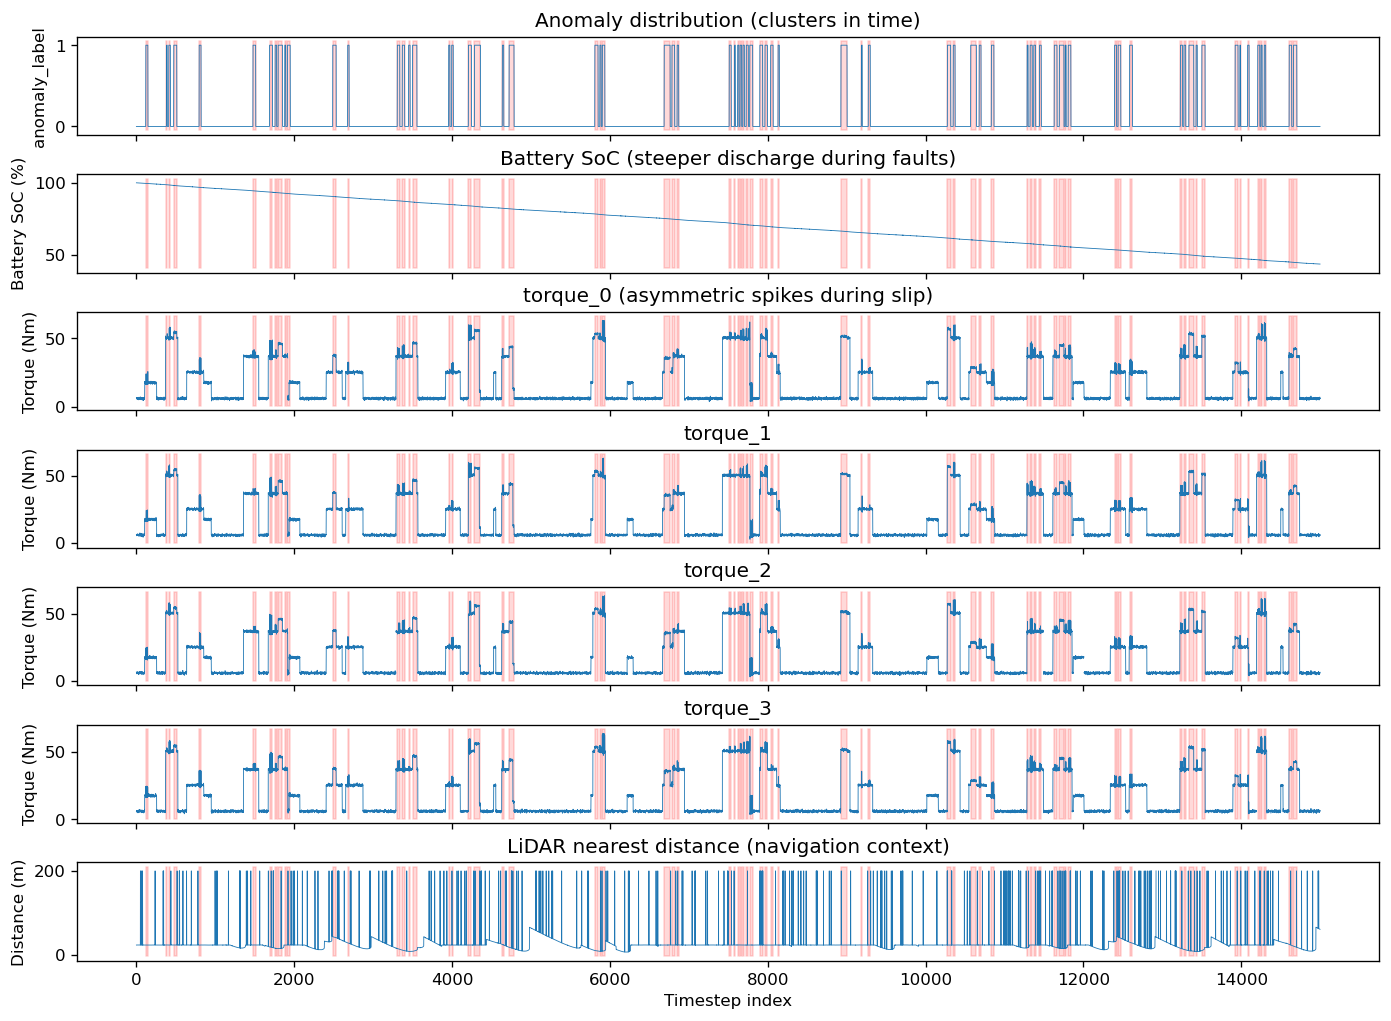

In [5]:
# ── Anomaly Distribution Plot ──────────────────────────────────
fig, axes = plt.subplots(7, 1, figsize=(14, 10), sharex=True)
fig.subplots_adjust(hspace=0.4)
t = np.arange(N_SAMPLES)

panels = [
    (df.anomaly_label.values, 'anomaly_label',   'Anomaly distribution (clusters in time)'),
    (df.battery_soc.values,   'Battery SoC (%)',  'Battery SoC (steeper discharge during faults)'),
    (df.torque_0.values,      'Torque (Nm)',      'torque_0 (asymmetric spikes during slip)'),
    (df.torque_1.values,      'Torque (Nm)',      'torque_1'),
    (df.torque_2.values,      'Torque (Nm)',      'torque_2'),
    (df.torque_3.values,      'Torque (Nm)',      'torque_3'),
    (df.lidar_distance.values,'Distance (m)',     'LiDAR nearest distance (navigation context)'),
]

for ax, (data, ylabel, title) in zip(axes, panels):
    ax.plot(t, data, lw=0.5)
    ax.fill_between(t, *ax.get_ylim(), where=anomaly_mask, color='red', alpha=0.15, step='mid')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[-1].set_xlabel('Timestep index')
plt.show()

### Channel distributions

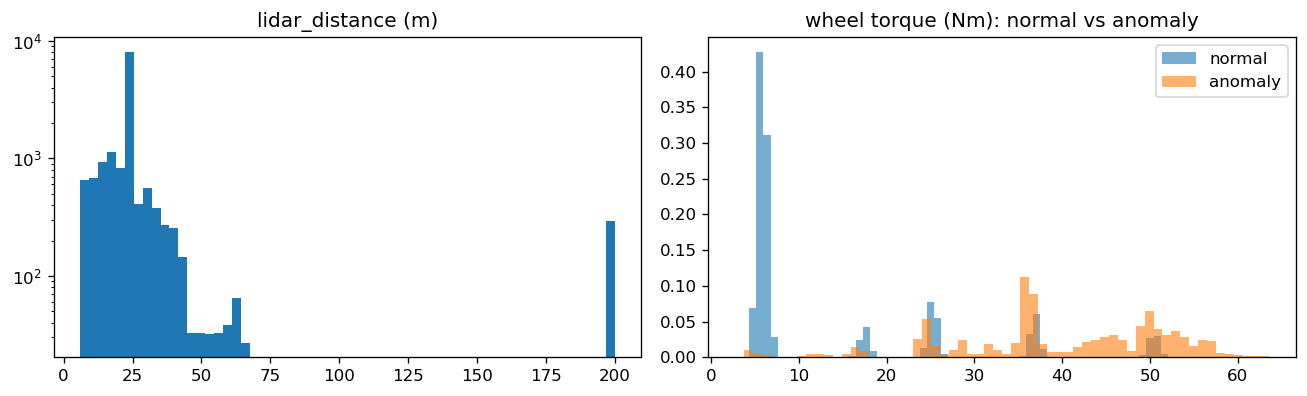

In [6]:
# ── Channel distributions (dataset validation, on the raw generated stream) ─────
tau_cols = ['torque_0', 'torque_1', 'torque_2', 'torque_3']
lab = df['anomaly_label'].to_numpy().astype(bool)
lidar = df['lidar_distance'].to_numpy(); lidar = lidar[~np.isnan(lidar)]
tau = df[tau_cols].to_numpy()
tn = tau[~lab].ravel(); tn = tn[~np.isnan(tn)]
ta = tau[lab].ravel();  ta = ta[~np.isnan(ta)]

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
axs[0].hist(lidar, bins=60); axs[0].set(title='lidar_distance (m)', yscale='log')
axs[1].hist(tn, bins=60, alpha=0.6, label='normal', density=True)
axs[1].hist(ta, bins=60, alpha=0.6, label='anomaly', density=True)
axs[1].set(title='wheel torque (Nm): normal vs anomaly'); axs[1].legend()
plt.tight_layout(); plt.show()

In [7]:
# ── Dataset summary ────────────────────────────────────────
from collections import Counter
info = pd.DataFrame([r['info'] for r in rows])

print('Dataset Summary')
print(f'Total rows     : {len(df):,}')
print(f'Sampling rate  : {FS} Hz')
print(f'Duration       : {len(df) * DT / 60:.1f} min')
print(f'Anomaly %      : {anomaly_mask.mean()*100:.1f}%  (causal slip/stuck self-faults)')
print(f'Fault events   : {info[info.fault.notna()].fault.value_counts().to_dict()}')
print(f'Terrain visits : {info.terrain.value_counts().to_dict()}')
print(f'Features       : {df.shape[1] - 1} sensor channels + 1 label')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Timestamp gaps : {(df.index.to_series().diff().dropna() != pd.Timedelta("100ms")).sum()}')
df.describe().round(3)

Dataset Summary
Total rows     : 15,000
Sampling rate  : 10.0 Hz
Duration       : 25.0 min
Anomaly %      : 15.1%  (causal slip/stuck self-faults)
Fault events   : {'slip': 1369, 'stuck': 889}
Terrain visits : {'asphalt': 8705, 'dry_grass': 2077, 'wet_grass': 2044, 'mud': 1302, 'gravel': 872}
Features       : 9 sensor channels + 1 label
Missing values : 718
Duplicate rows : 0
Timestamp gaps : 0


,gps_lat,gps_lon,lidar_distance,battery_soc,torque_0,torque_1,torque_2,torque_3,ambient_temp,anomaly_label
count,14932.000,14920.000,14919.000,14916.000,14923.000,14922.000,14925.000,14913.000,14912.000,15000.000
mean,1.351,103.801,26.270,71.748,17.856,17.836,17.872,17.853,27.997,0.151
std,0.000,0.001,25.941,16.266,15.991,15.979,16.005,16.003,2.123,0.358
min,1.350,103.800,6.100,43.452,3.576,2.751,3.016,3.463,24.705,0.000
25%,1.350,103.800,20.438,57.927,5.797,5.794,5.791,5.793,25.880,0.000
50%,1.351,103.801,23.074,72.110,6.430,6.440,6.446,6.447,27.991,0.000
75%,1.351,103.801,23.174,85.698,26.012,25.960,26.073,25.962,30.120,0.000
max,1.352,103.802,200.000,99.997,63.189,63.251,63.381,63.564,31.286,1.000


### Cleaning

In [8]:
df_raw = pd.read_csv(DATA_DIR / 'synthetic_rover_data.csv', index_col='timestamp', parse_dates=True)
sensor_cols = [c for c in df_raw.columns if c != 'anomaly_label']

null_before = df_raw[sensor_cols].isnull().sum()
print(f'Missing values before cleaning: {null_before.sum()}')

df_clean = df_raw.ffill().bfill()

quality_report = df_clean[sensor_cols].agg(['mean', 'std', 'min', 'max', 'skew', 'kurtosis']).T
quality_report['null_before'] = null_before
quality_report['null_after']  = df_clean[sensor_cols].isnull().sum()
quality_report['outliers_3std'] = (
    (df_clean[sensor_cols] - df_clean[sensor_cols].mean()).abs()
    > 3 * df_clean[sensor_cols].std()
).sum()
print('Data quality report (after cleaning):')
quality_report.round(3)

Missing values before cleaning: 718
Data quality report (after cleaning):


,mean,std,min,max,skew,kurtosis,null_before,null_after,outliers_3std
gps_lat,1.351,0.000,1.350,1.352,0.307,-1.039,68,0,0
gps_lon,103.801,0.001,103.800,103.802,0.187,-1.421,80,0,0
lidar_distance,26.281,25.956,6.100,200.000,5.961,36.946,81,0,298
battery_soc,71.738,16.265,43.452,99.997,-0.007,-1.188,84,0,0
torque_0,17.860,15.992,3.576,63.189,0.960,-0.492,77,0,0
torque_1,17.840,15.982,2.751,63.251,0.965,-0.481,78,0,0
torque_2,17.869,16.003,3.016,63.381,0.961,-0.491,75,0,0
torque_3,17.860,16.008,3.463,63.564,0.966,-0.476,87,0,0
ambient_temp,27.999,2.123,24.705,31.286,-0.000,-1.493,88,0,0


### Stratified Block Split

A single split governs every model by reading the same `rover_stratified_block_split.csv`. Use stratified block split because adjacent rows share up to 49/50 steps of the same FFT lookback window, and a single fault event (mean duration 31 steps) spans many rows, so a random split scatters near-duplicate, event-correlated rows across train/val/test. The fix operates at three levels:

1. **Blocks, not rows, are the split unit.** The timeline is cut into contiguous blocks at the midpoint of
   normal-only stretches long enough to host a cut (≥100 steps), targeting ~375-step blocks, merging any
   block that ends up under 300 steps into a neighbor. Every fault event therefore sits fully inside exactly
   one block — no event is ever split across train/val/test.
2. **Blocks are assigned to 7 folds with `StratifiedGroupKFold`**, which balances each fold's anomaly rate
   while keeping every row of a block on the same side.
3. **Purge:** the first 50 rows of every block (the largest lookback window used anywhere this week/next,
   `WINDOW_MAX=50`) are marked `purged` and excluded from every model's row set — this guarantees any row's
   lookback window never reaches across a block boundary into a different split, regardless of which
   window size (10/20/50) a given model uses.

**Choose val and test.** With only 23 blocks / 72 fault events, folds differ
not just in size but in the difficulty of the fault events they happen to contain (duration, severity mix)
— `StratifiedGroupKFold` only balances the row-level anomaly rate, not these other axes. Val and test roles
are assigned from structural statistics (event count, mean duration, anomaly rate vs. the dataset overall),
computed before any model is trained:

- **val** gets the fold structurally closest to the dataset's overall averages (anomaly rate, event
  duration): decisions made on val (hyperparameters, early stopping, decision thresholds) propagate to every
  downstream model with no correcting mechanism, so it should be the most representative fold available.
- **test** gets the next-closest fold: its single-fold number is allowed to carry a little more residual
  sampling noise, because the model_ledger/Pareto comparisons across models use a 7-fold rotation mean ± std
  (not the single canonical-fold number) as the actual performance claim (`W02_RF_Benchmark.ipynb`).
- **train** gets all remaining folds, including whichever fold is structurally most extreme — an unusual
  fold (very long events, unusually high/low anomaly rate) is a diversity asset for training, not a problem.

The result is one canonical row-level assignment (`block_id`, `fold_id`, `split`, `purged`) that every
notebook loads.

In [9]:
from sklearn.model_selection import StratifiedGroupKFold

WINDOW_MAX = 50                 # largest lookback window used anywhere (FFT / CNN / RNN / Transformer)
TARGET_BLOCK = 375              # target block length in steps
MIN_NORMAL_RUN_FOR_CUT = 100    # a normal run must be at least this long to host a cut
MIN_BLOCK_LEN = 300             # blocks shorter than this are merged into a neighbor
N_SPLITS = 7                    # StratifiedGroupKFold folds -> 5 train / 1 val / 1 test (~71/14/14)

label_full = df_clean['anomaly_label'].astype(int).values
N_full = len(label_full)

# ── contiguous normal (label==0) runs, candidates for a cut ─────────────
normal_runs = []
i = 0
while i < N_full:
    if label_full[i] == 0:
        j = i
        while j < N_full and label_full[j] == 0:
            j += 1
        normal_runs.append((i, j))
        i = j
    else:
        i += 1

# ── greedy cut placement at the midpoint of sufficiently long normal runs ──
cuts = [0]
last_cut = 0
for (s, e) in normal_runs:
    if (e - s) < MIN_NORMAL_RUN_FOR_CUT:
        continue
    mid = (s + e) // 2
    if mid - last_cut >= TARGET_BLOCK:
        cuts.append(mid)
        last_cut = mid
cuts.append(N_full)
blocks = [(cuts[i], cuts[i + 1]) for i in range(len(cuts) - 1)]

# ── merge any block shorter than MIN_BLOCK_LEN into a neighbor ─────────
def merge_short_blocks(blocks, min_len):
    blocks = blocks[:]
    changed = True
    while changed:
        changed = False
        for k, (s, e) in enumerate(blocks):
            if (e - s) < min_len and len(blocks) > 1:
                if k == 0:
                    blocks[k + 1] = (s, blocks[k + 1][1])
                elif k == len(blocks) - 1:
                    blocks[k - 1] = (blocks[k - 1][0], e)
                else:
                    left_len = blocks[k - 1][1] - blocks[k - 1][0]
                    right_len = blocks[k + 1][1] - blocks[k + 1][0]
                    if left_len <= right_len:
                        blocks[k - 1] = (blocks[k - 1][0], e)
                    else:
                        blocks[k + 1] = (s, blocks[k + 1][1])
                del blocks[k]
                changed = True
                break
    return blocks

blocks = merge_short_blocks(blocks, MIN_BLOCK_LEN)
print(f'{len(blocks)} blocks, lengths: {[e - s for s, e in blocks]}')

block_id_per_row = np.empty(N_full, dtype=int)
for bid, (s, e) in enumerate(blocks):
    block_id_per_row[s:e] = bid

# ── fault events (needed both for the leakage check below and the fold structural stats) ──
event_runs = []
i = 0
while i < N_full:
    if label_full[i] == 1:
        j = i
        while j < N_full and label_full[j] == 1:
            j += 1
        event_runs.append((i, j))
        i = j
    else:
        i += 1

# ── verify no fault event straddles a block boundary ────────────────────
n_split_events = sum(1 for (s, e) in event_runs if len(set(block_id_per_row[s:e])) > 1)
print(f'Events split across blocks: {n_split_events} / {len(event_runs)}')
assert n_split_events == 0

# ── purge: first WINDOW_MAX rows of every block are not valid anchors ──
purged = np.zeros(N_full, dtype=bool)
for (s, e) in blocks:
    purged[s:s + WINDOW_MAX] = True
print(f'Purged rows: {purged.sum()} / {N_full} ({purged.mean()*100:.1f}%)')

# ── assign blocks to 7 folds via StratifiedGroupKFold ───────────────────
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
row_idx_full = np.arange(N_full)
fold_of_row = np.empty(N_full, dtype=int)
for fold, (_, idx) in enumerate(sgkf.split(row_idx_full, label_full, groups=block_id_per_row)):
    fold_of_row[idx] = fold

# ── per-fold structural statistics, computed BEFORE any role is assigned ──
# (never choose val/test based on a score — only on structure available before training)
fold_stats = []
for f in range(N_SPLITS):
    fold_mask = fold_of_row == f
    fold_events = [(s, e) for (s, e) in event_runs if fold_of_row[s] == f]
    durations = [e - s for s, e in fold_events]
    fold_stats.append({
        'fold': f, 'n_events': len(fold_events),
        'mean_duration': np.mean(durations) if durations else 0.0,
        'anomaly_rate': label_full[fold_mask].mean(),
    })
fold_stats_df = pd.DataFrame(fold_stats)
overall_duration = np.mean([e - s for s, e in event_runs])
overall_rate = label_full.mean()
fold_stats_df['duration_dev'] = (fold_stats_df['mean_duration'] - overall_duration).abs()
fold_stats_df['rate_dev_pp'] = (fold_stats_df['anomaly_rate'] - overall_rate).abs() * 100
fold_stats_df['combined_dev'] = (fold_stats_df['duration_dev'] / overall_duration
                                  + fold_stats_df['rate_dev_pp'] / (overall_rate * 100))

print(f'Overall: mean event duration {overall_duration:.1f} steps, anomaly rate {overall_rate*100:.2f}%')
print('\nPer-fold structural statistics (computed before any role is assigned):')
print(fold_stats_df.round(3).to_string(index=False))

# ── val = most structurally representative fold; test = next-most; rest -> train ──
ranked = fold_stats_df.sort_values('combined_dev')['fold'].tolist()
VAL_FOLD, TEST_FOLD = ranked[0], ranked[1]
print(f'\nRanked by combined deviation from overall stats: {ranked}')
print(f'Selected: val = fold {VAL_FOLD} (most representative), test = fold {TEST_FOLD} (next-most)')

split_of_row = np.full(N_full, 'train', dtype=object)
split_of_row[fold_of_row == TEST_FOLD] = 'test'
split_of_row[fold_of_row == VAL_FOLD] = 'val'

# sanity: every block fully inside one split
block_to_splits = pd.Series(split_of_row).groupby(block_id_per_row).nunique()
assert (block_to_splits == 1).all(), 'a block spans multiple splits!'

print('\nRealized split proportions (all rows / anchor rows only):')
valid = ~purged
for name in ['train', 'val', 'test']:
    m_all, m_valid = split_of_row == name, (split_of_row == name) & valid
    print(f'  {name:5s}: {m_all.sum():>6,} rows ({m_all.mean()*100:4.1f}%), '
          f'anomaly={label_full[m_all].mean()*100:4.2f}%  |  '
          f'{m_valid.sum():>6,} anchor rows ({m_valid.sum()/valid.sum()*100:4.1f}%), '
          f'anomaly={label_full[m_valid].mean()*100:4.2f}%')

block_split_df = pd.DataFrame({
    'row_idx': row_idx_full, 'timestamp': df_clean.index,
    'block_id': block_id_per_row, 'fold_id': fold_of_row, 'split': split_of_row,
    'purged': purged, 'anomaly_label': label_full,
})
block_split_path = DATA_DIR / 'rover_stratified_block_split.csv'
block_split_df.to_csv(block_split_path, index=False)
print(f'\nSaved {block_split_path.resolve()}  shape={block_split_df.shape}')


23 blocks, lengths: [653, 495, 451, 620, 385, 397, 755, 743, 798, 1015, 880, 1346, 558, 692, 685, 604, 472, 569, 412, 395, 808, 422, 845]
Events split across blocks: 0 / 72
Purged rows: 1150 / 15000 (7.7%)
Overall: mean event duration 31.4 steps, anomaly rate 15.05%

Per-fold structural statistics (computed before any role is assigned):
 fold  n_events  mean_duration  anomaly_rate  duration_dev  rate_dev_pp  combined_dev
    0        12         24.417         0.168         6.944        1.757         0.338
    1        11         32.182         0.147         0.821        0.395         0.052
    2         9         33.778         0.148         2.417        0.231         0.092
    3         8         40.125         0.143         8.764        0.755         0.330
    4         9         33.667         0.140         2.306        1.090         0.146
    5        11         25.818         0.125         5.543        2.504         0.343
    6        12         33.250         0.189         1.889 

### FFT + Cross-Channel Physical Features

GPS is fed as **per-step deltas** (`gps_dlat`, `gps_dlon`), not absolute coordinates: on a fixed map
(`MAP_SEED=6`), absolute position is a memorized shortcut to "which spot on the loop", not a transferable
fault signal, whereas the slip/stuck mechanism is causally a displacement collapse — exactly what the delta
captures. Two cross-channel physical features (`inter_wheel_std` for slip, `stall_ratio` for stuck, each
with a 50-step rolling mean/max) are added because per-channel FFT statistics cannot express a relationship
between channels, and both fault mechanisms are defined by exactly such a relationship.


In [10]:
feature_matrix_full, feature_names, row_idx_array, label_array_full = build_feature_matrix(df_clean)

# ── filter by the block split's purge flag (drops each block's first WINDOW_MAX rows) ──
split_lookup = block_split_df.set_index('row_idx')
purged_mask = split_lookup.loc[row_idx_array, 'purged'].values
split_labels = split_lookup.loc[row_idx_array, 'split'].values
block_id_array = split_lookup.loc[row_idx_array, 'block_id'].values
fold_id_array = split_lookup.loc[row_idx_array, 'fold_id'].values

feature_matrix = feature_matrix_full[~purged_mask]
label_array = label_array_full[~purged_mask]
split_array = split_labels[~purged_mask]
block_id_array = block_id_array[~purged_mask]
fold_id_array = fold_id_array[~purged_mask]

print(f'Feature matrix (post-purge): {feature_matrix.shape}  (34 raw+FFT + 6 physical = 40)')
assert np.isnan(feature_matrix).sum() == 0

print('Feature matrix preview:')
pd.DataFrame(feature_matrix[:10], columns=feature_names).round(3)


Feature matrix (post-purge): (13850, 40)  (34 raw+FFT + 6 physical = 40)
Feature matrix preview:


,gps_dlat,gps_dlon,lidar_distance,battery_soc,torque_0,torque_1,torque_2,torque_3,ambient_temp,torque_0_dom_freq,...,lidar_distance_centroid,lidar_distance_bandwidth,lidar_distance_total_power,lidar_distance_peak_to_mean,inter_wheel_std,stall_ratio,inter_wheel_std_roll_mean,inter_wheel_std_roll_max,stall_ratio_roll_mean,stall_ratio_roll_max
0,-0.0,0.0,23.056,99.842,7.081,6.814,6.133,6.803,28.305,4.4,...,1.751,1.444,3.555,5.643,0.350,6704.792,0.242,0.483,5923.409,6836.907
1,0.0,0.0,200.000,99.838,5.682,6.182,6.394,6.178,28.131,4.4,...,1.750,1.434,3.510,5.631,0.262,6098.141,0.244,0.483,5934.467,6836.907
2,-0.0,0.0,23.125,99.835,5.234,5.326,6.066,5.371,28.211,4.4,...,2.601,1.442,782173.473,1.042,0.331,5493.557,0.246,0.483,5921.291,6836.907
3,0.0,0.0,23.101,99.832,5.668,5.559,6.271,5.569,28.013,1.4,...,2.600,1.442,782136.634,1.042,0.294,5765.050,0.249,0.483,5915.775,6836.907
4,-0.0,0.0,23.109,99.829,6.415,7.310,6.970,6.811,28.088,1.4,...,2.600,1.442,782136.598,1.042,0.322,6868.169,0.253,0.483,5940.319,6868.169
5,-0.0,0.0,23.118,99.826,5.685,5.325,5.614,5.693,27.994,1.4,...,2.600,1.442,782130.083,1.042,0.150,5574.025,0.251,0.483,5939.722,6868.169
6,0.0,0.0,23.115,99.823,6.376,6.563,6.161,6.481,28.054,1.4,...,2.600,1.442,782130.003,1.042,0.151,6388.172,0.251,0.483,5947.256,6868.169
7,-0.0,0.0,23.121,99.820,5.249,5.743,5.828,5.762,28.205,1.4,...,2.600,1.442,782125.754,1.042,0.231,5640.485,0.252,0.483,5933.218,6868.169
8,0.0,0.0,23.104,99.817,5.321,6.260,6.437,5.905,27.955,1.4,...,2.600,1.442,782125.754,1.042,0.427,5972.820,0.257,0.483,5929.744,6868.169
9,-0.0,0.0,23.173,99.814,5.442,5.491,6.208,5.965,27.946,1.4,...,2.600,1.442,782138.463,1.042,0.322,5770.335,0.257,0.483,5926.906,6868.169


### PCA

Components retained: 19 (from 40)
Variance explained : 0.9514


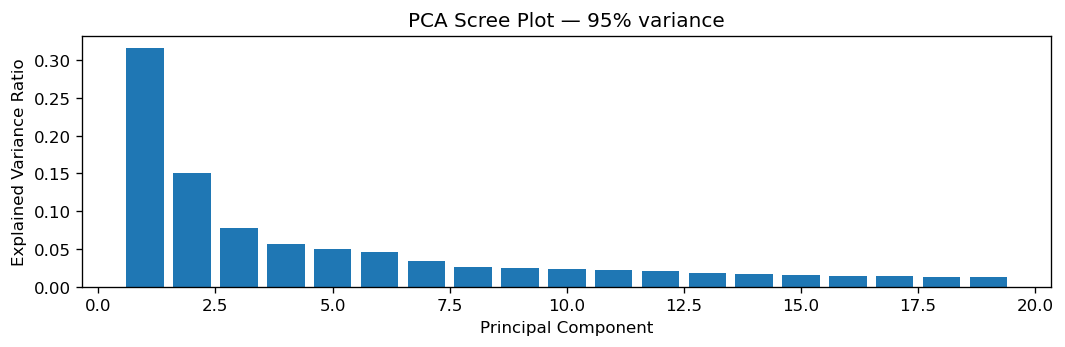

Top-5 loading features per PC:
PC1: ['torque_2_centroid', 'torque_0_centroid', 'torque_1_centroid', 'torque_3_centroid', 'torque_2_peak_to_mean']
PC2: ['stall_ratio', 'torque_3', 'torque_2', 'torque_0', 'torque_1']
PC3: ['lidar_distance_centroid', 'lidar_distance_peak_to_mean', 'lidar_distance_total_power', 'lidar_distance_dom_freq', 'lidar_distance_bandwidth']
PC4: ['torque_3_total_power', 'torque_2_total_power', 'torque_0_total_power', 'torque_1_total_power', 'ambient_temp']
PC5: ['torque_3_bandwidth', 'torque_1_bandwidth', 'torque_0_bandwidth', 'torque_2_bandwidth', 'inter_wheel_std_roll_mean']


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Partition by the canonical block split (no re-derivation) ──────────
train_mask = split_array == 'train'
val_mask   = split_array == 'val'
test_mask  = split_array == 'test'

X_tr_raw, y_tr_s = feature_matrix[train_mask], label_array[train_mask]
X_va_raw, y_va_s = feature_matrix[val_mask],   label_array[val_mask]
X_te_raw, y_te_s = feature_matrix[test_mask],  label_array[test_mask]
block_id_tr = block_id_array[train_mask]   # kept for GroupKFold CV in W02_RF_Benchmark.ipynb

# Fit scaler and PCA on train set
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_raw)
X_va_sc = scaler.transform(X_va_raw)
X_te_sc = scaler.transform(X_te_raw)

pca = PCA(n_components=0.95, random_state=SEED)
X_tr_s = pca.fit_transform(X_tr_sc)
X_va_s = pca.transform(X_va_sc)
X_te_s = pca.transform(X_te_sc)

print(f'Components retained: {pca.n_components_} (from {X_tr_raw.shape[1]})')
print(f'Variance explained : {pca.explained_variance_ratio_.sum():.4f}')

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(1, pca.n_components_+1), pca.explained_variance_ratio_)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Scree Plot — 95% variance')
plt.tight_layout()
plt.show()

print('Top-5 loading features per PC:')
for i in range(min(5, pca.n_components_)):
    top5 = pd.Series(np.abs(pca.components_[i]), index=feature_names).nlargest(5)
    print(f'PC{i+1}: {top5.index.tolist()}')


### RF Feature Selection

Top-K PCA components are selected by finding the minimal K within a threshold of the full-feature-set
score. Two candidate criteria are compared: **accuracy** and **F1**. Accuracy is a weak selection signal on
a 16%-anomaly task — a classifier that predicts "normal" for every row already scores ~84% — so it can rate
a feature subset "good enough" while a metric sensitive to the minority class disagrees. Both are computed
on the same importance-ranked component order; val F1 decides which criterion's resulting subset is
reported as the minimal-set finding.


Stratified block split (PCA feature space)
  train:  9,734  |  normal=8,134  anomaly=1,600  (16.4%)
  val  :  2,215  |  normal=1,861  anomaly=354  (16.0%)
  test :  1,901  |  normal=1,597  anomaly=304  (16.0%)

Baseline RF — all 19 PCA components — val acc: 94.63%  val F1: 0.8120
 done.

── Criterion comparison (both evaluated on val) ──────────────────────
Criterion    K  val_acc   val_f1
accuracy     4   93.05%   0.7701
F1           5   94.67%   0.8275

Selected criterion    : F1  (higher val F1 at its threshold-passing K)
Minimal top-K         : 5 component(s)
Top-K val accuracy    : 94.67%  (delta = -0.05 pp from full-set accuracy)
Top-K val F1          : 0.8275  (delta = -0.0155 from full-set F1)


,Component,Importance
Rank,,
1,PC1,0.1691
2,PC2,0.1538
3,PC12,0.1065
4,PC7,0.0866
5,PC17,0.0834


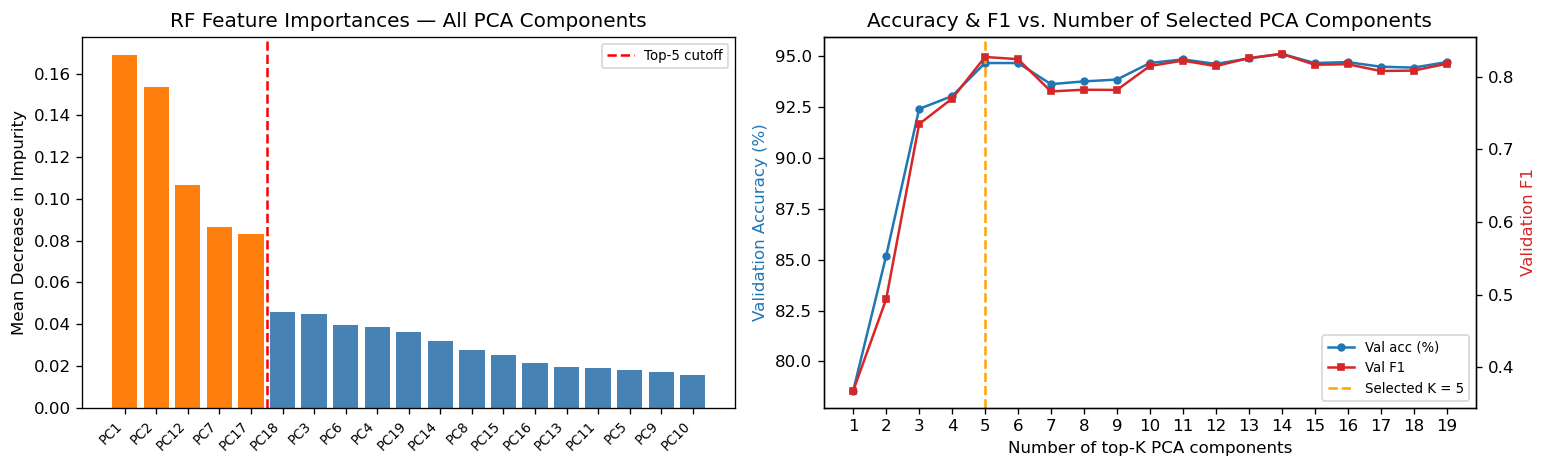


── Comparison: Aido Rover  vs.  CNC Wear Detection ──────────────────
  CNC result   : 97.81% test acc  |  2 raw sensor features (Z1 position)  |  direct feature space
  Rover result : 94.67% val acc / 0.8275 val F1  |  5 PCA component(s)  |  F1-selected
  CNC relies on raw positional features on a near-balanced task; Rover relies on a compact
  spectral + physical PCA representation selected by the metric sensitive to its 16% minority class.


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

# Split done in PCA cell; X_tr_s / X_va_s / X_te_s are PCA-transformed features
print('Stratified block split (PCA feature space)')
for name, y_split in [('train', y_tr_s), ('val', y_va_s), ('test', y_te_s)]:
    print(f'  {name:5s}: {len(y_split):>6,}  |  normal={(y_split==0).sum():,}  '
          f'anomaly={(y_split==1).sum():,}  ({(y_split==1).mean()*100:.1f}%)')

# ── Baseline RF on all PCA components ─────────────────────────────────────
n_pca_comps = X_tr_s.shape[1]
pca_names   = [f'PC{i+1}' for i in range(n_pca_comps)]

rf_full        = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_full.fit(X_tr_s, y_tr_s)
full_val_pred  = rf_full.predict(X_va_s)
full_val_acc   = accuracy_score(y_va_s, full_val_pred)
full_val_f1    = f1_score(y_va_s, full_val_pred)
importances    = rf_full.feature_importances_
order          = np.argsort(importances)[::-1]

print(f'\nBaseline RF — all {n_pca_comps} PCA components — val acc: {full_val_acc*100:.2f}%  val F1: {full_val_f1:.4f}')

# ── Accuracy AND F1 for each top-K (same importance-ranked order) ─────────
all_k_accs, all_k_f1s = [], []
for k in range(1, n_pca_comps + 1):
    idx_k = order[:k]
    rf_k  = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf_k.fit(X_tr_s[:, idx_k], y_tr_s)
    pred_k = rf_k.predict(X_va_s[:, idx_k])
    all_k_accs.append(accuracy_score(y_va_s, pred_k))
    all_k_f1s.append(f1_score(y_va_s, pred_k))
print(' done.')

# ── Minimal top-K within 2 pp / 0.02 of full-feature score, per criterion ──
threshold_acc = full_val_acc - 0.02
threshold_f1  = full_val_f1  - 0.02
best_k_acc    = next(k + 1 for k, a in enumerate(all_k_accs) if a >= threshold_acc)
best_k_f1     = next(k + 1 for k, f in enumerate(all_k_f1s)  if f >= threshold_f1)

print('\n── Criterion comparison (both evaluated on val) ──────────────────────')
print(f'{"Criterion":10s} {"K":>3s} {"val_acc":>8s} {"val_f1":>8s}')
print(f'{"accuracy":10s} {best_k_acc:>3d} {all_k_accs[best_k_acc-1]*100:>7.2f}% {all_k_f1s[best_k_acc-1]:>8.4f}')
print(f'{"F1":10s} {best_k_f1:>3d} {all_k_accs[best_k_f1-1]*100:>7.2f}% {all_k_f1s[best_k_f1-1]:>8.4f}')

# ── Decision: carry forward whichever criterion's subset has the higher val F1 ──
if all_k_f1s[best_k_f1 - 1] >= all_k_f1s[best_k_acc - 1]:
    winning_criterion, best_k = 'F1', best_k_f1
else:
    winning_criterion, best_k = 'accuracy', best_k_acc
best_acc_k = all_k_accs[best_k - 1]
best_f1_k  = all_k_f1s[best_k - 1]
best_idx   = order[:best_k].copy()
delta_pp   = (full_val_acc - best_acc_k) * 100

selected_names       = [pca_names[i] for i in best_idx]
selected_importances = importances[best_idx]

print(f'\nSelected criterion    : {winning_criterion}  (higher val F1 at its threshold-passing K)')
print(f'Minimal top-K         : {best_k} component(s)')
print(f'Top-K val accuracy    : {best_acc_k*100:.2f}%  (delta = {delta_pp:.2f} pp from full-set accuracy)')
print(f'Top-K val F1          : {best_f1_k:.4f}  (delta = {full_val_f1-best_f1_k:.4f} from full-set F1)')

feat_df = (pd.DataFrame({'Component': selected_names, 'Importance': selected_importances})
             .sort_values('Importance', ascending=False)
             .reset_index(drop=True))
feat_df.index = feat_df.index + 1
feat_df.index.name = 'Rank'
display(feat_df.round(4))

# ── Importance bar chart + accuracy/F1-vs-K curves ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['tab:orange' if i < best_k else 'steelblue' for i in range(n_pca_comps)]
axes[0].bar(range(n_pca_comps), importances[order], color=colors)
axes[0].set_xticks(range(n_pca_comps))
axes[0].set_xticklabels([pca_names[i] for i in order], rotation=45, ha='right', fontsize=8)
axes[0].axvline(best_k - 0.5, color='red', ls='--', lw=1.5, label=f'Top-{best_k} cutoff')
axes[0].set_ylabel('Mean Decrease in Impurity')
axes[0].set_title('RF Feature Importances — All PCA Components')
axes[0].legend(fontsize=8)

ax2 = axes[1].twinx()
l1, = axes[1].plot(range(1, n_pca_comps + 1), [a * 100 for a in all_k_accs], 'o-', ms=4, color='tab:blue', label='Val acc (%)')
l2, = ax2.plot(range(1, n_pca_comps + 1), all_k_f1s, 's-', ms=4, color='tab:red', label='Val F1')
axes[1].axvline(best_k, color='orange', ls='--', lw=1.5, label=f'Selected K = {best_k}')
axes[1].set_xlabel('Number of top-K PCA components')
axes[1].set_ylabel('Validation Accuracy (%)', color='tab:blue')
ax2.set_ylabel('Validation F1', color='tab:red')
axes[1].set_title('Accuracy & F1 vs. Number of Selected PCA Components')
axes[1].legend(handles=[l1, l2, axes[1].lines[-1]], fontsize=8, loc='lower right')
axes[1].set_xticks(range(1, n_pca_comps + 1))

plt.tight_layout()
plt.show()

# ── Comparison to CNC benchmark ────────────────────────────────────────────
print('\n── Comparison: Aido Rover  vs.  CNC Wear Detection ──────────────────')
print(f'  CNC result   : 97.81% test acc  |  2 raw sensor features (Z1 position)  |  direct feature space')
print(f'  Rover result : {best_acc_k*100:.2f}% val acc / {best_f1_k:.4f} val F1  |  {best_k} PCA component(s)  |  {winning_criterion}-selected')
print('  CNC relies on raw positional features on a near-balanced task; Rover relies on a compact')
print('  spectral + physical PCA representation selected by the metric sensitive to its 16% minority class.')


In [16]:
# ── Save outputs for W02_RF_Benchmark.ipynb ────────────────────────────
# Raw (pre-scale/PCA) arrays only — the benchmark notebook fits its own scaler+PCA+RF as a single
# sklearn Pipeline inside GridSearchCV, so no transform computed here should leak into its CV folds.
TEMP_DIR = DATA_DIR / 'temp'
TEMP_DIR.mkdir(exist_ok=True)

np.save(TEMP_DIR / 'X_tr_raw.npy', X_tr_raw)
np.save(TEMP_DIR / 'X_va_raw.npy', X_va_raw)
np.save(TEMP_DIR / 'X_te_raw.npy', X_te_raw)
np.save(TEMP_DIR / 'y_tr_s.npy',   y_tr_s)
np.save(TEMP_DIR / 'y_va_s.npy',   y_va_s)
np.save(TEMP_DIR / 'y_te_s.npy',   y_te_s)
np.save(TEMP_DIR / 'block_id_tr.npy', block_id_tr)   # groups for GroupKFold CV in W02_RF_Benchmark

# ── Full (all-split) raw arrays, for the 7-fold block-rotation robustness check ─────────────
np.save(TEMP_DIR / 'X_all_raw.npy',   feature_matrix)
np.save(TEMP_DIR / 'y_all.npy',       label_array)
np.save(TEMP_DIR / 'block_id_all.npy', block_id_array)
np.save(TEMP_DIR / 'fold_id_all.npy',  fold_id_array)   # canonical fold ids (from the CSV), for the rotation cell
np.save(TEMP_DIR / 'split_all.npy',   split_array)
print(f'Saved to {TEMP_DIR.resolve()}:')


Saved to /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/temp:
